# TP 1 - Problema 1: Clasificación Binaria (ACV)

Objetivo: predecir si un paciente tiene alto riesgo de accidente
cerebrovascular (ACV), a partir de datos clínicos y demográficos.

Dataset: `healthcare-dataset-stroke-data.csv`, 5110 pacientes, 12 columnas.
La variable objetivo es `stroke` (1 = alto riesgo, 0 = sin antecedentes).

Este notebook cubre las 7 consignas: análisis exploratorio,
preprocesamiento, diseño de la red, entrenamiento, evaluación, matriz de
confusión, y análisis y conclusiones.

**Cómo ejecutarlo en Colab.** Se sube la carpeta `datasets` de `tp1` a Google
Drive, dentro de `MyDrive/AA2_TP1/`. Se elige un entorno con GPU (Entorno de
ejecución, Cambiar tipo de entorno, GPU) y se ejecutan todas las celdas. La celda
de configuración monta Drive y usa `MyDrive/AA2_TP1` como carpeta de trabajo. Las
figuras quedan en esa carpeta. Fuera de Colab, el notebook corre en CPU con las
rutas locales.

In [1]:
import os
# Solo tiene efecto en GPU: cuBLAS determinista (se define antes de usar CUDA)
os.environ.setdefault('CUBLAS_WORKSPACE_CONFIG', ':4096:8')
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.impute import KNNImputer
from sklearn.metrics import (roc_auc_score, accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix,
                             precision_recall_curve)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Dispositivo y opciones deterministas para GPU
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
torch.use_deterministic_algorithms(True, warn_only=True)

# En Colab, los datos y las figuras van a la carpeta AA2_TP1 de Drive, con la misma estructura que tp1/
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    os.chdir('/content/drive/MyDrive/AA2_TP1')
print(f"Dispositivo: {DEVICE}, Colab: {IN_COLAB}, carpeta de trabajo: {os.getcwd()}")

plt.rcParams.update({
    'figure.figsize': (10, 4.5),
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'axes.grid': True,
    'grid.alpha': 0.3
})
sns.set_palette("muted")


Mounted at /content/drive
Dispositivo: cuda, Colab: True, carpeta de trabajo: /content/drive/MyDrive/AA2_TP1


El seed fijo (42) y el estilo de gráficos quedan configurados para el
resto del notebook. Sin este paso, cada corrida mezcla los datos de otra forma, y las figuras de dos ejecuciones no son comparables.

### Carga y verificación del dataset

Se lee el CSV y se muestran las dimensiones, los tipos de dato y las primeras
filas. Se verifica que coincidan con la tabla del enunciado (5110 pacientes y
12 columnas) antes de seguir.

In [2]:
DATA_PATH = "datasets/PROBLEMA 1/healthcare-dataset-stroke-data.csv"
df = pd.read_csv(DATA_PATH)

print(f"Filas: {df.shape[0]}, columnas: {df.shape[1]}")
df.info()
df.head()


Filas: 5110, columnas: 12
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


El dataset tiene 5110 filas y 12 columnas, sin valores nulos salvo en
`bmi` (se confirma más abajo). Los tipos de dato coinciden con la descripción del enunciado. `age`, `avg_glucose_level` y `bmi` son numéricos continuos. `hypertension`, `heart_disease` y `stroke` son binarios enteros. El resto son texto (categóricas).

### Estadísticas descriptivas

Se resume cada columna con `describe`. Para las numéricas se ven el rango, la
media y los cuantiles. Para las categóricas se ven la cantidad de niveles y el
nivel más frecuente. Se buscan valores extremos y columnas incompletas antes de
graficar.

In [3]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,5110.0,NaN,NaN,NaN,36517.829354,21161.721625,67.0,17741.25,36932.0,54682.0,72940.0
gender,5110,3,Female,2994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,5110.0,NaN,NaN,NaN,43.226614,22.612647,0.08,25.0,45.0,61.0,82.0
hypertension,5110.0,NaN,NaN,NaN,0.097456,0.296607,0.0,0.0,0.0,0.0,1.0
heart_disease,5110.0,NaN,NaN,NaN,0.054012,0.226063,0.0,0.0,0.0,0.0,1.0
ever_married,5110,2,Yes,3353,NaN,NaN,NaN,NaN,NaN,NaN,NaN
work_type,5110,5,Private,2925,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Residence_type,5110,2,Urban,2596,NaN,NaN,NaN,NaN,NaN,NaN,NaN
avg_glucose_level,5110.0,NaN,NaN,NaN,106.147677,45.28356,55.12,77.245,91.885,114.09,271.74
bmi,4909.0,NaN,NaN,NaN,28.893237,7.854067,10.3,23.5,28.1,33.1,97.6


`age` va de 0.08 a 82 años (bebés incluidos), y `avg_glucose_level` de 55 a 272 mg/dL. `bmi` va de 10.3 a 97.6, con solo 4909 valores no nulos sobre 5110 filas. El máximo de `bmi` (97.6) es un valor extremo. Confirma el sesgo hacia la derecha del histograma de la sección 1.2.

## 1. Análisis Exploratorio de Datos (EDA)

Esta sección revisa la distribución de la variable objetivo, el desbalance de clases y la correlación de cada predictor con `stroke`. Se usan histogramas, boxplots y mapas de calor.

### 1.1 Distribución de la variable objetivo y desbalance de clases

stroke = 1 (alto riesgo): 249 pacientes (4.87%)
stroke = 0 (sin antecedentes): 4861 pacientes (95.13%)
Razon de desbalance (neg/pos): 19.5 a 1


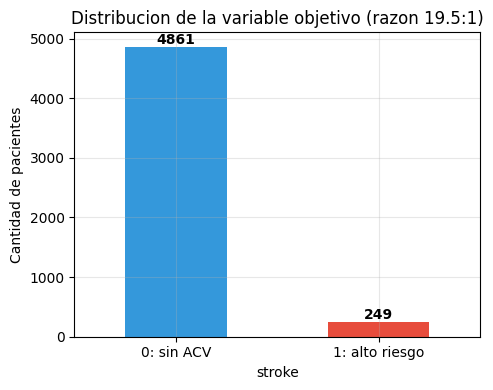

In [4]:
n_pos = int(df['stroke'].sum())
n_neg = len(df) - n_pos
ratio = n_neg / n_pos

print(f"stroke = 1 (alto riesgo): {n_pos} pacientes ({n_pos/len(df)*100:.2f}%)")
print(f"stroke = 0 (sin antecedentes): {n_neg} pacientes ({n_neg/len(df)*100:.2f}%)")
print(f"Razon de desbalance (neg/pos): {ratio:.1f} a 1")

fig, ax = plt.subplots(figsize=(5, 4))
df['stroke'].value_counts().sort_index().plot(
    kind='bar', ax=ax, color=['#3498db', '#e74c3c'])
ax.set_xticklabels(['0: sin ACV', '1: alto riesgo'], rotation=0)
ax.set_ylabel('Cantidad de pacientes')
ax.set_title(f'Distribucion de la variable objetivo (razon {ratio:.1f}:1)')
for i, v in enumerate(df['stroke'].value_counts().sort_index()):
    ax.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('p1_01_distribucion_target.png', dpi=110, bbox_inches='tight')
plt.show()


Solo 249 de 5110 pacientes (4.87%) tienen `stroke = 1`, una razón de
19.5 casos negativos por cada positivo. Este desbalance es el punto de partida de dos decisiones posteriores. Son la métrica de evaluación (sección 5) y la estrategia de class weighting (sección 2e). Las dos dependen de esta proporción.

### 1.2 Distribución de los predictores numéricos (histogramas)

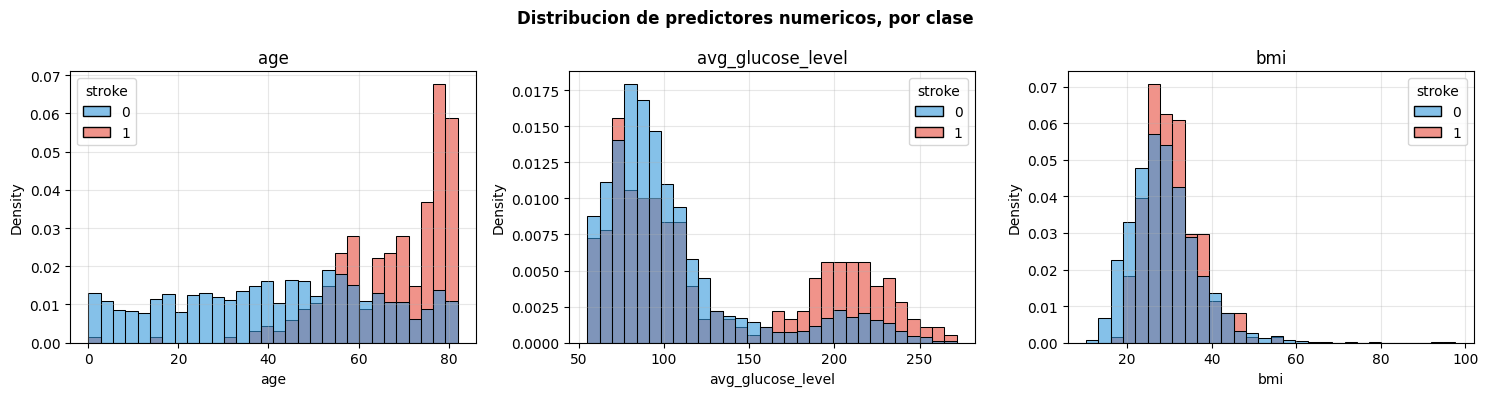

In [5]:
num_cols = ['age', 'avg_glucose_level', 'bmi']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(data=df, x=col, hue='stroke', bins=30, ax=ax,
                 palette={0: '#3498db', 1: '#e74c3c'}, alpha=0.6,
                 stat='density', common_norm=False)
    ax.set_title(col)
fig.suptitle('Distribucion de predictores numericos, por clase', fontweight='bold')
plt.tight_layout()
plt.savefig('p1_02_histogramas_numericos.png', dpi=110, bbox_inches='tight')
plt.show()


En los tres histogramas, la clase `stroke = 1` (rojo) está corrida hacia
valores más altos que `stroke = 0` (azul), sobre todo en `age`. En
`avg_glucose_level` aparecen dos grupos dentro de la clase positiva, uno
cerca de 80-100 mg/dL y otro por encima de 150 mg/dL. `bmi` muestra una
diferencia más chica entre clases que las otras dos variables.

### 1.3 Predictores numéricos frente al riesgo de ACV (boxplots)

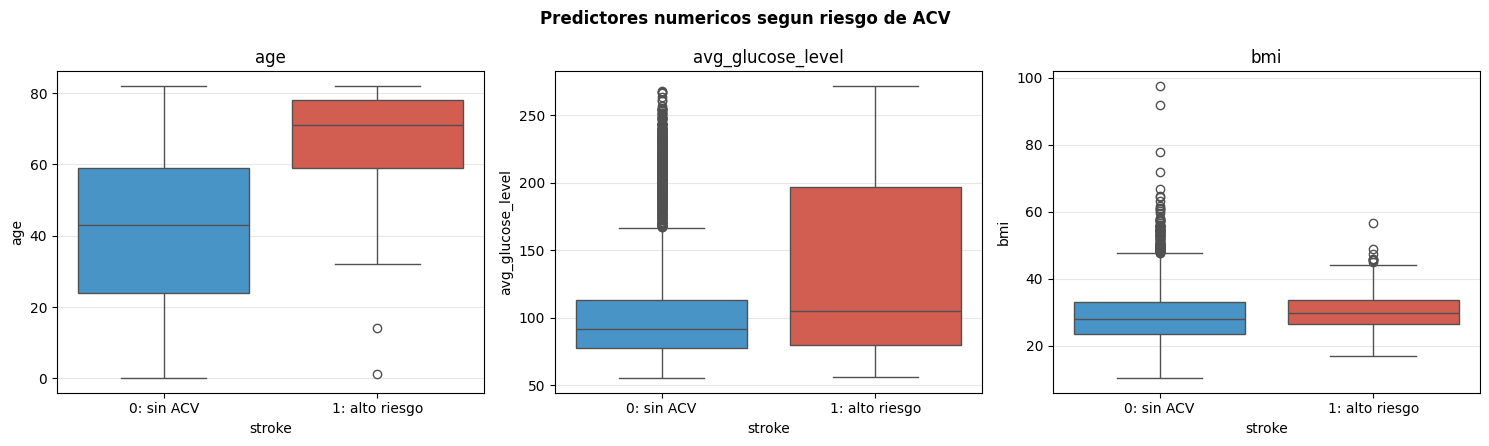

         age  avg_glucose_level   bmi
stroke                               
0       43.0              91.47  28.0
1       71.0             105.22  29.7


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df, x='stroke', y=col, ax=ax, hue='stroke',
                palette={0: '#3498db', 1: '#e74c3c'}, legend=False)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['0: sin ACV', '1: alto riesgo'])
    ax.set_title(col)
fig.suptitle('Predictores numericos segun riesgo de ACV', fontweight='bold')
plt.tight_layout()
plt.savefig('p1_03_boxplots_numericos.png', dpi=110, bbox_inches='tight')
plt.show()

print(df.groupby('stroke')[num_cols].median())


La mediana de `age` es 71 años en pacientes con ACV y 43 años sin ACV. Es una diferencia de 28 años, la más grande de las tres variables.
`avg_glucose_level` también es más alto en el grupo con ACV (105.22 frente
a 91.47). La mediana de `bmi` casi no cambia entre clases (29.7 frente a 28.0). Esto anticipa la correlación baja de la sección 1.5.

### 1.4 Tasa de ACV por variable categórica y binaria

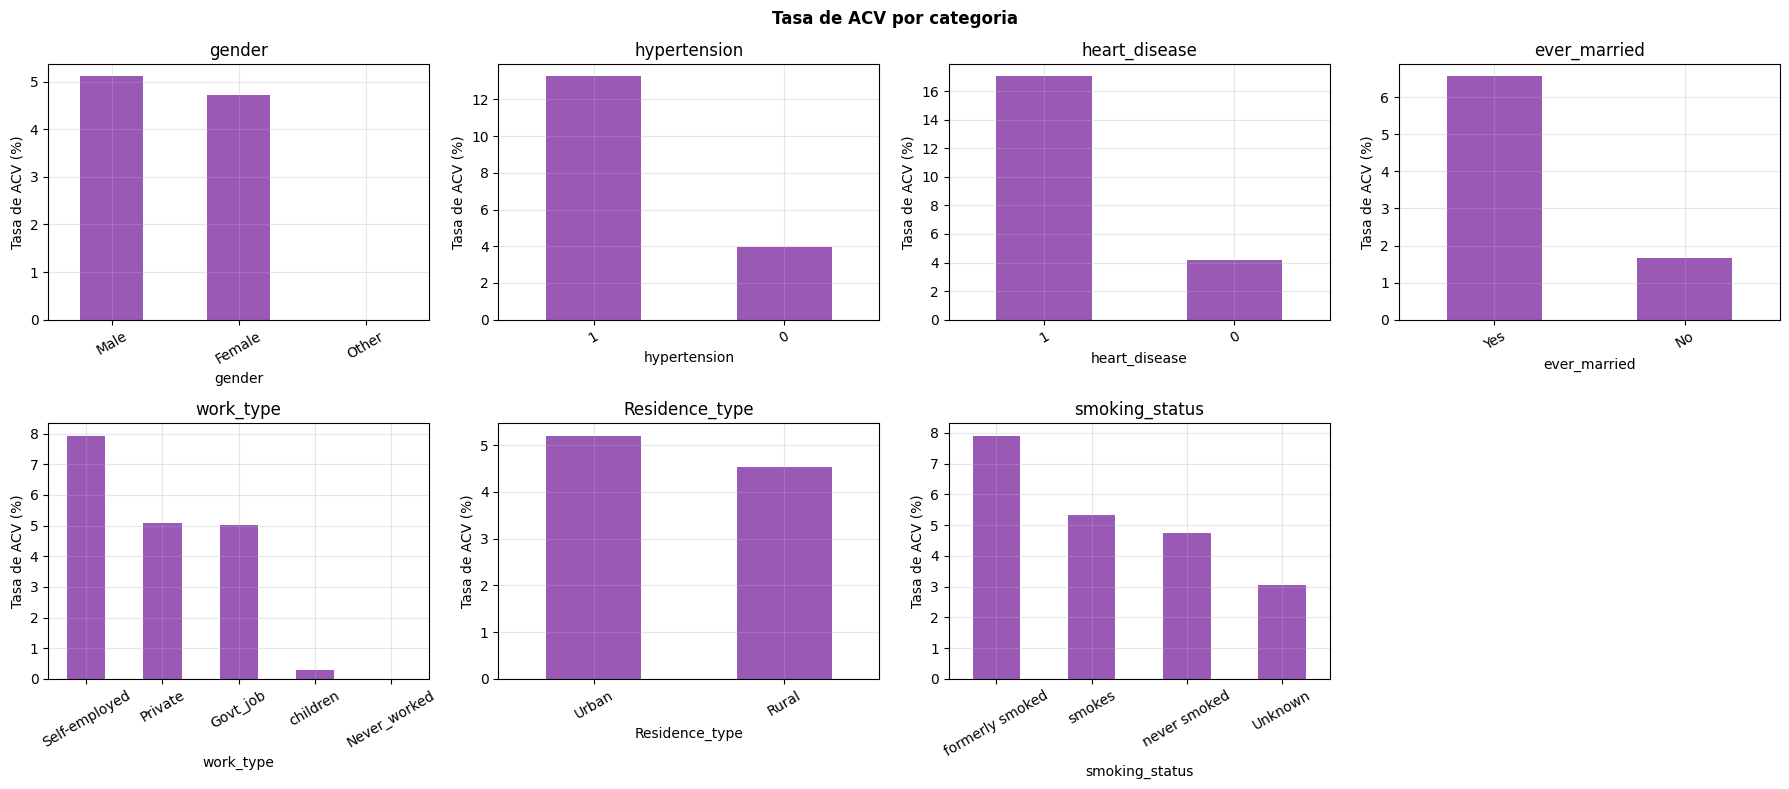

In [7]:
cat_cols = ['gender', 'hypertension', 'heart_disease', 'ever_married',
            'work_type', 'Residence_type', 'smoking_status']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()
for ax, col in zip(axes, cat_cols):
    rate = df.groupby(col)['stroke'].mean().sort_values(ascending=False) * 100
    rate.plot(kind='bar', ax=ax, color='#9b59b6')
    ax.set_ylabel('Tasa de ACV (%)')
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=30)
axes[-1].axis('off')
fig.suptitle('Tasa de ACV por categoria', fontweight='bold')
plt.tight_layout()
plt.savefig('p1_04_tasa_por_categoria.png', dpi=110, bbox_inches='tight')
plt.show()


La tasa de ACV es mayor en pacientes con `heart_disease = 1` (17%, frente
a 4% sin la enfermedad) y con `hypertension = 1` (13%, frente a 4%). Entre
las variables de estilo de vida, `work_type = Self-employed` tiene la
tasa más alta (8%), coherente con que ese grupo suele ser de mayor edad.
`gender` y `Residence_type` muestran una diferencia chica entre
categorías, y son señales más débiles que las variables de historial
médico.

### 1.5 Correlación de las variables numéricas y binarias con `stroke`

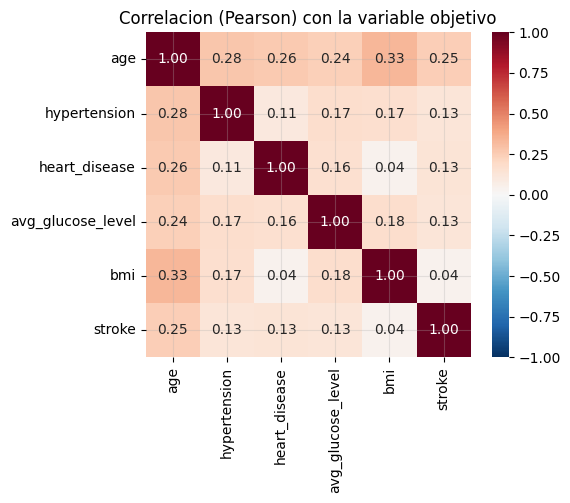

stroke               1.000000
age                  0.245257
heart_disease        0.134914
avg_glucose_level    0.131945
hypertension         0.127904
bmi                  0.042374
Name: stroke, dtype: float64


In [8]:
corr_cols = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level',
             'bmi', 'stroke']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('Correlacion (Pearson) con la variable objetivo')
plt.tight_layout()
plt.savefig('p1_05_correlacion.png', dpi=110, bbox_inches='tight')
plt.show()

print(corr['stroke'].sort_values(ascending=False))


`age` tiene la correlación más alta con `stroke` (0.245), seguida de
`heart_disease` (0.135), `avg_glucose_level` (0.132) y `hypertension`
(0.128). `bmi` tiene la correlación más baja (0.042), lo que confirma la
diferencia chica de medianas vista en la sección 1.3. Estas cuatro
variables con correlación más alta son las señales principales que el
modelo debe aprender a combinar.

### 1.6 Valores faltantes

Se cuentan los valores faltantes por columna. El enunciado indica que `bmi`
tiene faltantes. Se verifica si es la única columna con ese problema, porque
la estrategia de imputación de la sección 2 depende de eso.

In [9]:
# Valores faltantes por columna, relevante para el preprocesamiento
# posterior (imputacion de bmi).
df.isna().sum()


,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


`bmi` es la única columna con datos faltantes: 201 de 5110 filas (3.9%).
Todas las demás columnas están completas. Esto confirma que la
imputación, en la sección de preprocesamiento, solo necesita cubrir
`bmi`.

### Conclusiones del EDA

El dataset tiene un desbalance fuerte: los pacientes con `stroke = 1` son
una fracción pequeña del total. Una regla que siempre predice "sin ACV"
tiene una exactitud (accuracy) alta, pero no detecta ningún caso de riesgo.

`age` es el predictor más fuerte, con la correlación más alta con `stroke`
entre las variables numéricas. Los histogramas y los gráficos de caja
muestran una edad mayor en el grupo con ACV. `hypertension`, `heart_disease` y `avg_glucose_level` también muestran una relación clara con el riesgo. La tasa de ACV es mayor en pacientes con hipertensión o enfermedad cardíaca. La mediana de glucosa es más alta en el grupo con ACV.

`bmi` tiene valores faltantes, que la sección de preprocesamiento debe
imputar antes de entrenar cualquier modelo.

## 2. Preprocesamiento

El trabajo sigue siempre este orden. Primero se dividen los datos en train, val y test. Después se ajusta cada transformación (imputación, codificación, escalado) solo con train. Esto
evita la fuga de información (*data leakage*) hacia validación y test.

### 2a. Eliminar columnas y filas sin señal

- Se elimina `id`. Es un identificador de paciente, sin relación con el
  riesgo de ACV.
- Se elimina la única fila con `gender = Other`. Con un solo caso, la red no aprende un patrón. Además, una división estratificada no pone esa fila en train, val y test al mismo tiempo.

In [10]:
# 2a. Eliminar columna id y la fila con gender == 'Other'
df_p = df.drop(columns=['id'])

n_other = int((df_p['gender'] == 'Other').sum())
print(f"Filas con gender == 'Other': {n_other}")

df_p = df_p[df_p['gender'] != 'Other'].reset_index(drop=True)
print(f"Filas antes: {len(df)}, filas despues: {len(df_p)}, "
      f"columnas: {df_p.shape[1]}")


Filas con gender == 'Other': 1
Filas antes: 5110, filas despues: 5109, columnas: 11


Quedan 5109 filas y 11 columnas: se eliminaron `id` y la única fila con
`gender = Other`. `df_p` es el DataFrame de trabajo para el resto del
preprocesamiento.

### División en train / val / test

Se divide `df_p` en tres conjuntos, estratificados por `stroke`. Así train, val y test conservan la misma proporción de clases (19.5 : 1). Se usan 70% train, 15% val, 15% test. Esta división
se hace antes de imputar, codificar o escalar, para que esos pasos
siguientes se ajusten solo con datos de entrenamiento.

In [11]:
y = df_p['stroke'].values
X = df_p.drop(columns=['stroke'])

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)

print(f"Train: {len(X_train)} filas ({y_train.mean()*100:.2f}% positivos)")
print(f"Val:   {len(X_val)} filas ({y_val.mean()*100:.2f}% positivos)")
print(f"Test:  {len(X_test)} filas ({y_test.mean()*100:.2f}% positivos)")


Train: 3576 filas (4.87% positivos)
Val:   766 filas (4.83% positivos)
Test:  767 filas (4.95% positivos)


Los tres conjuntos quedan con una proporción de positivos cercana al
4.87% original, lo que confirma que la estratificación funcionó. Train
tiene 3576 filas, val 766 filas y test 767 filas.

### 2b. Imputación de `bmi`

`bmi` tiene 201 valores faltantes. Su distribución tiene sesgo, con una cola larga de valores altos (sección 1.2). Por eso la mediana es un relleno más robusto que la media frente a los valores extremos.

Se calcula la mediana solo con el conjunto de entrenamiento, y se aplica
ese mismo valor a validación y test.

La sección 7.2 compara otras cuatro estrategias, incluso no usar `bmi`. Solo
la mediana con un indicador de faltante supera dos errores estándar, con un efecto chico.

In [12]:
# 2b. Imputar bmi con la mediana del conjunto de entrenamiento
bmi_median = X_train['bmi'].median()
print(f"Mediana de bmi (train): {bmi_median:.2f}")
print(f"Faltantes antes -> train: {X_train['bmi'].isna().sum()}, "
      f"val: {X_val['bmi'].isna().sum()}, test: {X_test['bmi'].isna().sum()}")

for split in (X_train, X_val, X_test):
    split['bmi'] = split['bmi'].fillna(bmi_median)

print(f"Faltantes despues -> train: {X_train['bmi'].isna().sum()}, "
      f"val: {X_val['bmi'].isna().sum()}, test: {X_test['bmi'].isna().sum()}")


Mediana de bmi (train): 27.90
Faltantes antes -> train: 141, val: 29, test: 31
Faltantes despues -> train: 0, val: 0, test: 0


La mediana de `bmi` en el conjunto de entrenamiento es 27.90, cercana a
la mediana de todo el dataset (28.10, sección 1). El conjunto de entrenamiento tenía 141 valores faltantes, val 29 y test 31. Después del relleno, ningún conjunto tiene valores faltantes.

### 2c. Codificación de variables categóricas

- `gender` y `ever_married` tienen dos valores: mapeo directo a 0/1.
- `work_type`, `Residence_type` y `smoking_status` tienen tres o más
  valores, sin un orden natural entre ellos: one-hot encoding.

Un código numérico simple (label encoding) en estas últimas impone un orden falso entre categorías, por ejemplo `Private > Govt_job`.

In [13]:
# 2c. Codificar variables categoricas
binary_map_gender = {'Female': 0, 'Male': 1}
binary_map_married = {'No': 0, 'Yes': 1}
onehot_cols = ['work_type', 'Residence_type', 'smoking_status']

def encode(split):
    out = split.copy()
    out['gender'] = out['gender'].map(binary_map_gender)
    out['ever_married'] = out['ever_married'].map(binary_map_married)
    return pd.get_dummies(out, columns=onehot_cols)

X_train_enc = encode(X_train)
X_val_enc = encode(X_val)
X_test_enc = encode(X_test)

# Alinear columnas por si alguna categoria no aparece en un split
X_val_enc = X_val_enc.reindex(columns=X_train_enc.columns, fill_value=0)
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

print(f"Columnas antes de codificar: {X_train.shape[1]}")
print(f"Columnas despues de codificar: {X_train_enc.shape[1]}")
print(f"Columnas nuevas (one-hot): "
      f"{[c for c in X_train_enc.columns if c not in X_train.columns]}")


Columnas antes de codificar: 10
Columnas despues de codificar: 18
Columnas nuevas (one-hot): ['work_type_Govt_job', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'Residence_type_Rural', 'Residence_type_Urban', 'smoking_status_Unknown', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes']


Las columnas de entrada pasan de 10 a 18. `gender` y `ever_married` quedan en una columna cada una (0/1). `work_type` (5 categorías), `Residence_type` (2) y `smoking_status` (4) pasan a 11 columnas binarias, una por categoría.

### 2d. Escalado de variables numéricas continuas

`age`, `avg_glucose_level` y `bmi` están en escalas muy distintas (años,
mg/dL, un índice). Se usa z-score (`StandardScaler`):

```
x_escalado = (x - media_train) / desvio_train
```

Se ajustan la media y el desvío solo con el conjunto de entrenamiento, y
se usan esos mismos valores para escalar validación y test.

Se eligió z-score en lugar de min-max scaling por dos razones:

- `avg_glucose_level` y `bmi` tienen outliers (sección 1.3). Min-max
  scaling comprime la mayoría de los valores en un rango angosto cuando
  unos pocos outliers fijan el mínimo o el máximo. Z-score es menos
  sensible a ese efecto.
- Z-score es el estándar para entradas de una red entrenada con descenso
  por gradiente, porque deja cada feature en una escala comparable.

Las columnas binarias y one-hot ya están en [0, 1] y no se escalan.

In [14]:
# 2d. Escalar variables numericas continuas (ajustado solo con train)
scale_cols = ['age', 'avg_glucose_level', 'bmi']

scaler = StandardScaler()
X_train_s = X_train_enc.copy()
X_val_s = X_val_enc.copy()
X_test_s = X_test_enc.copy()

X_train_s[scale_cols] = scaler.fit_transform(X_train_enc[scale_cols])
X_val_s[scale_cols] = scaler.transform(X_val_enc[scale_cols])
X_test_s[scale_cols] = scaler.transform(X_test_enc[scale_cols])

feature_cols = list(X_train_s.columns)
print(f"Media / desvio en train luego de escalar:")
print(X_train_s[scale_cols].agg(['mean', 'std']))
print(f"\nMedia / desvio en test luego de escalar (con parametros de train):")
print(X_test_s[scale_cols].agg(['mean', 'std']))


Media / desvio en train luego de escalar:
               age  avg_glucose_level           bmi
mean  6.755720e-17       1.529972e-16  2.086325e-16
std   1.000140e+00       1.000140e+00  1.000140e+00

Media / desvio en test luego de escalar (con parametros de train):
           age  avg_glucose_level       bmi
mean  0.022072           0.052387  0.063006
std   0.979654           1.052465  0.997159


En train, las tres columnas escaladas quedan con media 0 y desvío 1, como
se espera de `StandardScaler`. En test, la media y el desvío no son
exactamente 0 y 1: se aplicaron los parámetros de train, no unos nuevos
ajustados sobre test. Esa diferencia chica es normal, y confirma que no
hubo fuga de información de test hacia el escalado.

### 2e. Estrategia frente al desbalance de clases (19.5 : 1)

Se eligió **class weighting**, en lugar de submuestreo, SMOTE o sobremuestreo a mano. La función de costo penaliza más el error sobre la clase positiva (`pos_weight` de `BCEWithLogitsLoss`). Entrena sobre los datos originales, sin duplicar filas ni generar
datos sintéticos, y evita un problema propio de SMOTE con columnas
binarias/one-hot. En un contexto clínico, un falso negativo es más
costoso que un falso positivo. Esa fue la motivación inicial del class
weighting.

Comparación completa de las tres estrategias en `informe.md`.

Nota: la sección 7.1 mide el efecto real de esta decisión. El class
weighting cambia las probabilidades de la red, pero no mejora la
detección cuando el umbral se elige sobre validación.

In [15]:
# 2e. Calcular pos_weight para la funcion de costo (class weighting)
n_pos_train = int(y_train.sum())
n_neg_train = len(y_train) - n_pos_train
pos_weight_value = n_neg_train / n_pos_train

print(f"Positivos en train: {n_pos_train}, negativos en train: {n_neg_train}")
print(f"pos_weight (neg/pos): {pos_weight_value:.2f}")

pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32)


Positivos en train: 174, negativos en train: 3402
pos_weight (neg/pos): 19.55


`pos_weight` queda en 19.55 (3402 negativos y 174 positivos en train), muy
cerca de la razón de desbalance de todo el dataset (19.5, sección 1). Este
valor se usa en `BCEWithLogitsLoss` en la sección de entrenamiento del
modelo (sección 3).

## 3. Diseño e implementación de la red neuronal

Diseño elegido para el MLP de clasificación binaria:

- **Capas ocultas y neuronas** (3a): 3 capas ocultas, 64 -> 32 -> 16
  neuronas. El problema tiene solo 18 features de entrada y 3576 filas de
  entrenamiento (174 positivas), así que se eligió una red chica. La
  sección 7.2 mide cinco tamaños, de 449 a 46081 parámetros, y ninguno
  cambia el AUC de validación de forma medible. La idea inicial era
  que una red más grande sobreajusta más. La medición no lo sostiene.
- **Activación oculta** (3b): Leaky ReLU (`negative_slope = 0.01`), en
  lugar de ReLU. Con ReLU común, una neurona queda "muerta" si su suma ponderada es negativa para todos los ejemplos. Ahí el gradiente de ReLU es 0, y ningún paso futuro la revive. Leaky ReLU deja un
  gradiente chico (0.01) en la zona negativa. Es una precaución que sigue
  el apunte de la Unidad 1 (donde Leaky ReLU es la alternativa a ReLU
  para capas ocultas). Al principio se pensó que `pos_weight` aumentaba
  ese riesgo. La sección 7.1 mide el efecto y no encuentra una diferencia
  con ReLU, así que la elección es preventiva y no demostrada.
- **Activación de salida** (3b): ninguna, un logit. Se usa
  `BCEWithLogitsLoss`, que aplica la sigmoid de forma interna, más
  estable numéricamente que aplicar sigmoid y después `BCELoss` por
  separado. Se rechazó softmax con 2 salidas. En un problema binario equivale a sigmoid con 1 salida, pero con un parámetro redundante. Además, no tiene un equivalente directo de `pos_weight`.
- **Función de costo** (3c): `BCEWithLogitsLoss` con
  `pos_weight = 19.55` (sección 2e), para compensar el desbalance de
  clases dentro de la función de costo.
- **Inicialización de pesos**: Kaiming/He (`nn.init.kaiming_normal_`,
  `nonlinearity='leaky_relu'`) en cada capa lineal, en lugar de dejar el
  default de PyTorch sin nombrarlo. Xavier/Glorot calibra la varianza de
  los pesos asumiendo que la activación no cambia mucho la escala de la
  señal. ReLU y Leaky ReLU descartan (o casi descartan) la mitad de los
  valores negativos, lo que reduce la varianza a la mitad en cada capa.
  Kaiming corrige eso con `Var(w) = 2 / n_in`, para mantener la varianza
  estable capa a capa en redes ReLU. El default de `nn.Linear` usa
  `kaiming_uniform_` con `a = sqrt(5)`, con varianza `1 / (3 n_in)`, unas
  6 veces menor. Se declaró Kaiming de forma explícita para fijar el
  `nonlinearity` correcto (Leaky ReLU, no ReLU) y para documentarlo como
  una decisión de diseño. La sección 7.2 no encuentra diferencia de AUC
  con el default (+0.0013, error estándar 0.0034).
- **Regularización** (3e): Dropout (0.3) entre las capas ocultas, para
  reducir el sobreajuste dado el conjunto de entrenamiento chico. Se
  combina con Early Stopping en la sección de entrenamiento (sección 4).
  La sección 7.2 mide Dropout de 0.0 a 0.5 y no encuentra diferencia
  medible de AUC. El valor 0.3 está en el rango de los ejemplos del
  apunte de la Unidad 4.

In [16]:
class StrokeMLP(nn.Module):
    """MLP de clasificacion binaria: n_features -> hidden_sizes -> 1 logit."""

    def __init__(self, n_features, dropout=0.3, leaky_slope=0.01,
                 hidden_sizes=(64, 32, 16), kaiming_init=True):
        super().__init__()
        layers = []
        in_features = n_features
        for position, out_features in enumerate(hidden_sizes):
            layers.append(nn.Linear(in_features, out_features))
            layers.append(nn.LeakyReLU(leaky_slope))
            # Dropout entre capas ocultas, no antes de la capa de salida
            if position < len(hidden_sizes) - 1:
                layers.append(nn.Dropout(dropout))
            in_features = out_features
        layers.append(nn.Linear(in_features, 1))
        self.net = nn.Sequential(*layers)
        if kaiming_init:
            self._init_weights(leaky_slope)

    def _init_weights(self, leaky_slope):
        # Kaiming/He, ajustado a la pendiente negativa de Leaky ReLU.
        # La capa de salida (sin activacion no lineal) usa 'linear'.
        linear_layers = [m for m in self.net if isinstance(m, nn.Linear)]
        for layer in linear_layers[:-1]:
            nn.init.kaiming_normal_(
                layer.weight, a=leaky_slope, nonlinearity='leaky_relu')
            nn.init.zeros_(layer.bias)
        nn.init.kaiming_normal_(
            linear_layers[-1].weight, nonlinearity='linear')
        nn.init.zeros_(linear_layers[-1].bias)

    def forward(self, x):
        # squeeze(-1): (batch, 1) -> (batch,), para que la forma calce
        # con las etiquetas en BCEWithLogitsLoss
        return self.net(x).squeeze(-1)


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = StrokeMLP(n_features=X_train_s.shape[1]).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
first_layer_std = model.net[0].weight.std().item()
print(f"Device: {DEVICE}")
print(f"Parametros entrenables: {n_params}")
print(f"Desvio de los pesos de la primera capa (Kaiming init): "
      f"{first_layer_std:.4f}")
print(model)


Device: cuda
Parametros entrenables: 3841
Desvio de los pesos de la primera capa (Kaiming init): 0.3371
StrokeMLP(
  (net): Sequential(
    (0): Linear(in_features=18, out_features=64, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): LeakyReLU(negative_slope=0.01)
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): LeakyReLU(negative_slope=0.01)
    (8): Linear(in_features=16, out_features=1, bias=True)
  )
)


El modelo tiene 4 capas lineales (18 -> 64 -> 32 -> 16 -> 1). Las capas ocultas usan Leaky ReLU, Dropout e inicialización Kaiming/He, según el diseño de esta sección. Tiene 3841 parámetros entrenables y 3576 filas de entrenamiento, una relación cercana a 1. Es razonable para una red chica, y apoya un ancho decreciente en lugar de una red más grande. El desvío estándar de los pesos de la primera capa es 0.3371. Confirma que se aplicó la inicialización Kaiming explícita, y no el valor por defecto.

### Preparar los datos para PyTorch

Se convierten los DataFrames escalados (sección 2) en `TensorDataset` y
`DataLoader` de PyTorch, uno por cada conjunto (train, val, test).
Se usa un batch size de 64, chico en relación a train (3576 filas). Con el desbalance de clases, cada batch tiene en promedio unos 3 ejemplos positivos (174 / 3576 x 64).

In [17]:
def to_tensor_dataset(df_x, y_arr):
    x_tensor = torch.tensor(df_x.values.astype(np.float32))
    y_tensor = torch.tensor(y_arr.astype(np.float32))
    return TensorDataset(x_tensor, y_tensor)


BATCH_SIZE = 64

train_dataset = to_tensor_dataset(X_train_s, y_train)
val_dataset = to_tensor_dataset(X_val_s, y_val)
test_dataset = to_tensor_dataset(X_test_s, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Batches por epoca -> train: {len(train_loader)}, "
      f"val: {len(val_loader)}, test: {len(test_loader)}")


Batches por epoca -> train: 56, val: 12, test: 12


Los tres `DataLoader` quedan listos para el entrenamiento: 56 batches por
época en train, 12 en val y 12 en test. `train_loader` mezcla los datos en cada época (`shuffle=True`). `val_loader` y `test_loader` no los mezclan, porque el orden no cambia la evaluación. Un orden fijo hace más fácil revisar predicciones puntuales.

## 4. Entrenamiento y curvas de aprendizaje

Se entrena el `StrokeMLP` con las decisiones de la sección 3 y estas
decisiones adicionales:

- **Optimizador**: Adam, tasa de aprendizaje `1e-3`. Adam ajusta la tasa
  de cada parámetro de forma individual y converge rápido en MLPs chicos.
- **Máximo de épocas**: 100. Es un techo. El Early Stopping corta antes.
- **Early Stopping**: monitorea la pérdida de validación (`val_loss`). Si
  no mejora durante 10 épocas seguidas, el entrenamiento se detiene y el
  modelo vuelve a los pesos de la mejor época.
- **Métrica de seguimiento**: AUC-ROC, además de la pérdida. Con un
  desbalance de 19.5 a 1, la accuracy es engañosa: un modelo que siempre
  predice "sin ACV" ya tiene una accuracy cercana a 95%. AUC-ROC no
  depende del umbral ni de la proporción de clases.
- **Métrica en train**: se calculan la pérdida y el AUC-ROC de train con el
  modelo en modo `eval()` (sin Dropout) al final de cada época. Así la
  comparación con validación es justa.

In [18]:
def evaluate(model, loader, criterion):
    """Devuelve (perdida promedio, AUC-ROC, probabilidades, etiquetas)."""
    model.eval()
    total_loss = 0.0
    all_logits, all_labels = [], []
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)
            logits = model(x_batch)
            total_loss += criterion(logits, y_batch).item() * len(x_batch)
            all_logits.append(logits.cpu())
            all_labels.append(y_batch.cpu())
    logits = torch.cat(all_logits).numpy()
    labels = torch.cat(all_labels).numpy()
    probs = 1 / (1 + np.exp(-logits))
    avg_loss = total_loss / len(loader.dataset)
    return avg_loss, roc_auc_score(labels, probs), probs, labels


# Funcion de costo con class weighting (seccion 2e) y optimizador Adam
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(DEVICE))
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

MAX_EPOCHS = 100
PATIENCE = 10
MIN_DELTA = 1e-4

history = {'train_loss': [], 'val_loss': [], 'train_auc': [], 'val_auc': []}
best_val_loss = float('inf')
best_state = None
best_epoch = 0
epochs_without_improvement = 0

for epoch in range(1, MAX_EPOCHS + 1):
    # Un paso de entrenamiento sobre todos los batches de train
    model.train()
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(x_batch), y_batch)
        loss.backward()
        optimizer.step()

    # Metricas de fin de epoca, en modo eval (sin Dropout)
    train_loss, train_auc, _, _ = evaluate(model, train_loader, criterion)
    val_loss, val_auc, _, _ = evaluate(model, val_loader, criterion)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_auc'].append(train_auc)
    history['val_auc'].append(val_auc)

    # Early Stopping sobre val_loss
    if val_loss < best_val_loss - MIN_DELTA:
        best_val_loss = val_loss
        best_epoch = epoch
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epoch == 1 or epoch % 5 == 0:
        print(f"Epoca {epoch:3d} | train_loss={train_loss:.4f} "
              f"val_loss={val_loss:.4f} | train_auc={train_auc:.4f} "
              f"val_auc={val_auc:.4f}")

    if epochs_without_improvement >= PATIENCE:
        print(f"\nEarly Stopping en la epoca {epoch}.")
        break

# Volver a los pesos de la mejor epoca
model.load_state_dict(best_state)
print(f"Mejor epoca: {best_epoch} (val_loss={best_val_loss:.4f}, "
      f"val_auc={history['val_auc'][best_epoch - 1]:.4f})")


Epoca   1 | train_loss=1.1092 val_loss=1.1089 | train_auc=0.7834 val_auc=0.7857
Epoca   5 | train_loss=0.9177 val_loss=0.9861 | train_auc=0.8477 val_auc=0.8259
Epoca  10 | train_loss=0.8715 val_loss=0.9726 | train_auc=0.8631 val_auc=0.8331
Epoca  15 | train_loss=0.8329 val_loss=0.9900 | train_auc=0.8720 val_auc=0.8321
Epoca  20 | train_loss=0.8158 val_loss=1.0137 | train_auc=0.8778 val_auc=0.8263

Early Stopping en la epoca 20.
Mejor epoca: 10 (val_loss=0.9726, val_auc=0.8331)


El entrenamiento se detuvo por Early Stopping en la época 20. La mejor
época fue la 10, con `val_loss = 0.9726` y `val_auc = 0.8331`. El modelo
conserva los pesos de esa época.

La pérdida de train baja en casi todas las épocas (de 1.1092 a 0.8158). La pérdida de validación baja de 1.11 a cerca de 0.99 en las primeras 4
épocas. Después oscila entre 0.97 y 1.00, con su mínimo en la época 10. En las últimas épocas sube hasta 1.0137. La
mejor época cambia con la semilla: en la variante base de la sección 7.2 va
de 2 a 6. En este modelo es la 10, fuera de ese rango, y la parada ocurrió en la época 20. Los valores de pérdida son altos porque `pos_weight = 19.55`
multiplica el costo de cada positivo. No se comparan con una BCE sin
ponderar.

### 4.1 Curvas de aprendizaje

Se grafican la pérdida y el AUC-ROC por época, en train y en validación.
Una brecha creciente entre las dos curvas indica sobreajuste. Dos curvas
altas y juntas indican subajuste. La línea vertical marca la época cuyos
pesos conserva el modelo.

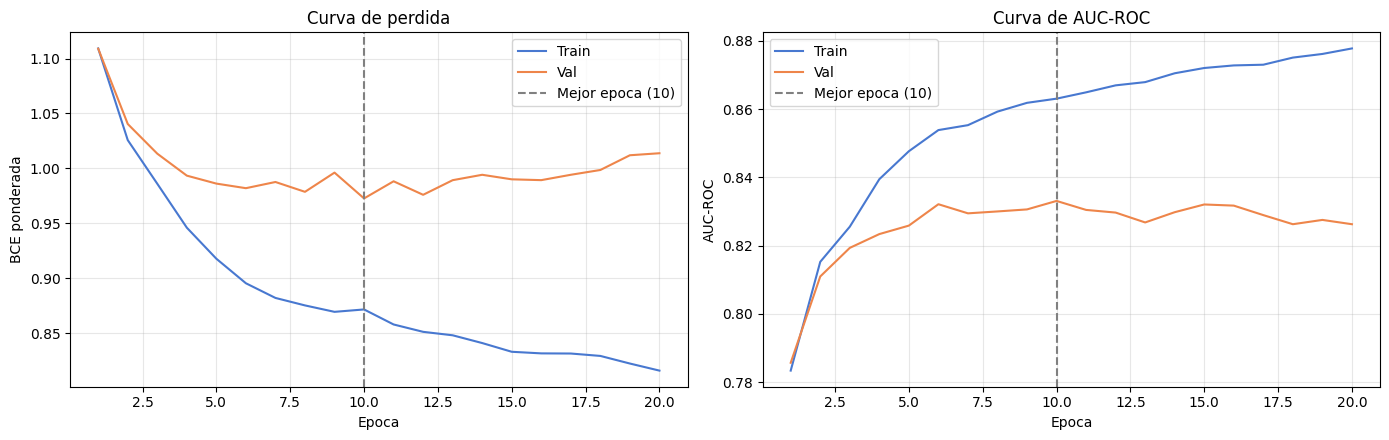

En la mejor epoca (10):
  brecha de perdida (val - train): +0.1011
  brecha de AUC (train - val):     +0.0300
Ultima epoca (20): train_loss=0.8158, val_loss=1.0137


In [19]:
epochs_range = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(epochs_range, history['train_loss'], label='Train')
axes[0].plot(epochs_range, history['val_loss'], label='Val')
axes[0].axvline(best_epoch, color='gray', linestyle='--',
                label=f'Mejor epoca ({best_epoch})')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('BCE ponderada')
axes[0].set_title('Curva de perdida')
axes[0].legend()

axes[1].plot(epochs_range, history['train_auc'], label='Train')
axes[1].plot(epochs_range, history['val_auc'], label='Val')
axes[1].axvline(best_epoch, color='gray', linestyle='--',
                label=f'Mejor epoca ({best_epoch})')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('AUC-ROC')
axes[1].set_title('Curva de AUC-ROC')
axes[1].legend()

plt.tight_layout()
plt.savefig('p1_06_curvas_entrenamiento.png', dpi=110, bbox_inches='tight')
plt.show()

gap_loss = history['val_loss'][best_epoch - 1] - history['train_loss'][best_epoch - 1]
gap_auc = history['train_auc'][best_epoch - 1] - history['val_auc'][best_epoch - 1]
print(f"En la mejor epoca ({best_epoch}):")
print(f"  brecha de perdida (val - train): {gap_loss:+.4f}")
print(f"  brecha de AUC (train - val):     {gap_auc:+.4f}")
print(f"Ultima epoca ({len(history['train_loss'])}): "
      f"train_loss={history['train_loss'][-1]:.4f}, "
      f"val_loss={history['val_loss'][-1]:.4f}")


**Diagnóstico.** Hay sobreajuste leve, sin subajuste.

- *Sin subajuste*: el AUC-ROC de validación llega a 0.83, muy por encima
  de 0.5 (un clasificador al azar). La red aprende señal real.
- *Sobreajuste leve*: en la mejor época, la pérdida de validación supera a la de train por 0.1011. El AUC de train supera al de validación por 0.0300. Después de la época 10 la brecha crece: train sigue mejorando y
  validación se estanca. Es el patrón que describe el apunte de la
  Unidad 4.
- *Regularización*: Dropout (0.3) y Early Stopping limitan el
  sobreajuste, pero no lo eliminan. Con solo 174 positivos en train, la
  red memoriza parte de ellos.

**Observación.** El AUC de validación llega a su valor más alto cerca de la época 10 (0.8331). Es la misma época del mínimo de la pérdida de validación. En esta corrida, los dos criterios coinciden. Se eligió parar por pérdida porque es el criterio de la
sección 4. La pérdida también es más estable que el AUC con solo 37 positivos en
validación. Después de la época 10, el AUC de validación baja poco a poco hasta 0.8263.

## 5. Evaluación del modelo

### 5.1 Elección del umbral de decisión

La red devuelve una probabilidad. Para decidir "alto riesgo" o "sin
riesgo" hace falta un umbral. El umbral 0.5 no es neutral en este
problema: `pos_weight = 19.55` empuja a la red a dar probabilidades altas,
y con 0.5 marca a muchos pacientes sanos como de riesgo.

Se elige el umbral sobre el conjunto de **validación**, con esta regla:

> maxima precision, entre los umbrales con recall mayor o igual a 0.70.

Razones:

- En un contexto clínico, un falso negativo cuesta más que un falso
  positivo. La regla fija un piso de recall (0.70) y, dentro de ese piso,
  reduce las falsas alarmas.
- Se usa validación y no test. El conjunto de test se usa una sola vez,
  al final, con el umbral ya fijado.
- Se prueban umbrales de 0.01 a 0.99, en pasos de 0.01.

In [20]:
# Probabilidades del modelo sobre validacion (mejor epoca, seccion 4)
_, _, val_probs, val_labels = evaluate(model, val_loader, criterion)

MIN_RECALL = 0.70
threshold_grid = np.round(np.arange(0.01, 1.00, 0.01), 2)

rows = []
for threshold in threshold_grid:
    val_preds = (val_probs >= threshold).astype(int)
    rows.append({
        'umbral': threshold,
        'precision': precision_score(val_labels, val_preds, zero_division=0),
        'recall': recall_score(val_labels, val_preds, zero_division=0),
        'f1': f1_score(val_labels, val_preds, zero_division=0),
    })
threshold_table = pd.DataFrame(rows)

# Regla: maxima precision entre los umbrales con recall >= MIN_RECALL
eligible = threshold_table[threshold_table['recall'] >= MIN_RECALL]
best_row = eligible.loc[eligible['precision'].idxmax()]
chosen_threshold = float(best_row['umbral'])

print(f"Umbrales que cumplen recall >= {MIN_RECALL}: {len(eligible)} de "
      f"{len(threshold_table)}")
print(f"Umbral elegido: {chosen_threshold:.2f}")
print(f"  precision={best_row['precision']:.3f}  "
      f"recall={best_row['recall']:.3f}  f1={best_row['f1']:.3f}")
print("\nUmbrales vecinos:")
print(threshold_table[
    threshold_table['umbral'].between(chosen_threshold - 0.05,
                                      chosen_threshold + 0.05)
].round(3).to_string(index=False))


Umbrales que cumplen recall >= 0.7: 57 de 99
Umbral elegido: 0.51
  precision=0.138  recall=0.811  f1=0.236

Umbrales vecinos:
 umbral  precision  recall    f1
   0.46      0.124   0.838 0.215
   0.47      0.126   0.838 0.219
   0.48      0.130   0.838 0.225
   0.49      0.134   0.838 0.230
   0.50      0.135   0.811 0.231
   0.51      0.138   0.811 0.236
   0.52      0.132   0.757 0.225
   0.53      0.134   0.757 0.228
   0.54      0.134   0.730 0.227
   0.55      0.135   0.730 0.228
   0.56      0.137   0.730 0.231


57 de los 99 umbrales cumplen recall >= 0.70. El de mayor precisión es
**0.51**, con precisión 0.138, recall 0.811 y F1 0.236 en validación.

El umbral elegido queda casi en 0.50, y no en el borde del piso. A 0.51, el modelo detecta
30 de los 37 positivos de validación (30 / 37 = 0.811). A 0.52 detecta 28
y el recall baja a 0.757, todavía sobre el piso. Entre 0.49 y 0.56 la
precisión casi no cambia (de 0.132 a 0.138). La regla elige el máximo de una
curva casi plana. Pocos pacientes de diferencia en validación cambian el
umbral elegido. Con 37 positivos, esta regla es sensible al ruido.

### 5.2 Métricas sobre el conjunto de test

Se evalúa el modelo en test **una sola vez**, con el umbral fijado en la
sección 5.1. Como referencia, se muestra también el umbral 0.5.

Se reportan Accuracy, Precision, Recall, F1-Score y AUC-ROC. La tabla incluye una regla trivial que siempre predice "sin ACV". Muestra que la accuracy no sirve como métrica principal con un desbalance de 19.5 a 1.

In [21]:
# Unica evaluacion sobre test
_, test_auc, test_probs, test_labels = evaluate(model, test_loader, criterion)

def metrics_at(threshold):
    preds = (test_probs >= threshold).astype(int)
    return {
        'Accuracy': accuracy_score(test_labels, preds),
        'Precision': precision_score(test_labels, preds, zero_division=0),
        'Recall': recall_score(test_labels, preds, zero_division=0),
        'F1-Score': f1_score(test_labels, preds, zero_division=0),
        'AUC-ROC': test_auc,
    }

always_negative = np.zeros_like(test_labels)
baseline = {
    'Accuracy': accuracy_score(test_labels, always_negative),
    'Precision': 0.0, 'Recall': 0.0, 'F1-Score': 0.0, 'AUC-ROC': 0.5,
}

results = pd.DataFrame({
    f'Umbral elegido ({chosen_threshold:.2f})': metrics_at(chosen_threshold),
    'Umbral 0.50': metrics_at(0.5),
    'Siempre "sin ACV"': baseline,
}).T
print(f"Test: {len(test_labels)} pacientes, {int(test_labels.sum())} positivos")
print(results.round(4).to_string())


Test: 767 pacientes, 38 positivos
                       Accuracy  Precision  Recall  F1-Score  AUC-ROC
Umbral elegido (0.51)    0.7001     0.1160  0.7632    0.2014   0.8177
Umbral 0.50              0.6923     0.1163  0.7895    0.2027   0.8177
Siempre "sin ACV"        0.9505     0.0000  0.0000    0.0000   0.5000


**Resultado con el umbral elegido (0.51).** El modelo detecta 29 de los 38
pacientes con ACV (recall 0.7632) y deja pasar 9. La precisión es 0.1160:
de cada 9 alertas, unas 8 son falsas alarmas. El AUC-ROC en test es 0.8177,
cercano al 0.8331 de validación.

**El piso de recall se sostuvo en test.** En validación el recall era
0.811. En test es 0.7632, por encima del piso. El modelo detecta 29 casos, y el piso pide 26.6 (0.70 x 38). El recall bajó unos 5 puntos de validación a test. Hay dos causas probables. Primero, el umbral se eligió
sobre validación, y esa elección es optimista para validación. Segundo,
con 37 y 38 positivos, un paciente mueve el recall unos 2.7 puntos. No se ajustó el umbral otra vez con test, porque eso invalida la evaluación.

**Umbral 0.50 frente a 0.51.** Con 0.50 el modelo detecta 30 de 38
positivos (recall 0.7895) y genera 228 falsas alarmas. Con 0.51
detecta 29 y genera 221. Ganar 1 positivo cuesta 7 falsas
alarmas más. Los dos umbrales casi no se diferencian. En test, 0.50 tiene incluso un F1 un poco mayor (0.2027 frente a 0.2014).

**Qué métrica es la mejor y cuál engaña.**

- *Accuracy engaña.* La regla que siempre predice "sin ACV" tiene accuracy 0.9505, y no detecta ningún caso. Es mayor que la del modelo en los dos umbrales (0.7001 y 0.6923). Con un desbalance de 19.5 a 1, la
  accuracy premia ignorar la clase minoritaria.
- *AUC-ROC es la mejor para comparar modelos.* No depende del umbral ni de
  la proporción de clases. Mide si la red ordena a los pacientes de mayor
  a menor riesgo. Un valor de 0.82 indica que la red aprende señal real.
- *Recall y precisión juntos describen el punto de operación.* Recall
  responde cuántos casos reales se detectan. Precisión responde cuántas
  alertas son ciertas. En este caso, el recall pesa más por el costo de un falso negativo. Pero con una precisión de 0.12, actuar sobre cada alerta es poco práctico.

## 6. Matriz de confusión

Se visualiza la matriz de confusión sobre el conjunto de test, con el
umbral elegido (0.51) y con 0.50 como referencia. No es una segunda
evaluación: usa las mismas predicciones de la sección 5.2.

Cada celda muestra la cantidad de pacientes y el porcentaje dentro de su
fila (la clase real). Se eligieron porcentajes por fila, y no sobre el total,
porque la clase positiva es solo el 5% de los datos. Un porcentaje sobre el total oculta los falsos negativos.

- **Verdadero negativo (TN)**: sin ACV, el modelo dice sin riesgo.
- **Falso positivo (FP)**: sin ACV, el modelo dice alto riesgo (falsa alarma).
- **Falso negativo (FN)**: con ACV, el modelo dice sin riesgo (caso perdido).
- **Verdadero positivo (TP)**: con ACV, el modelo dice alto riesgo.

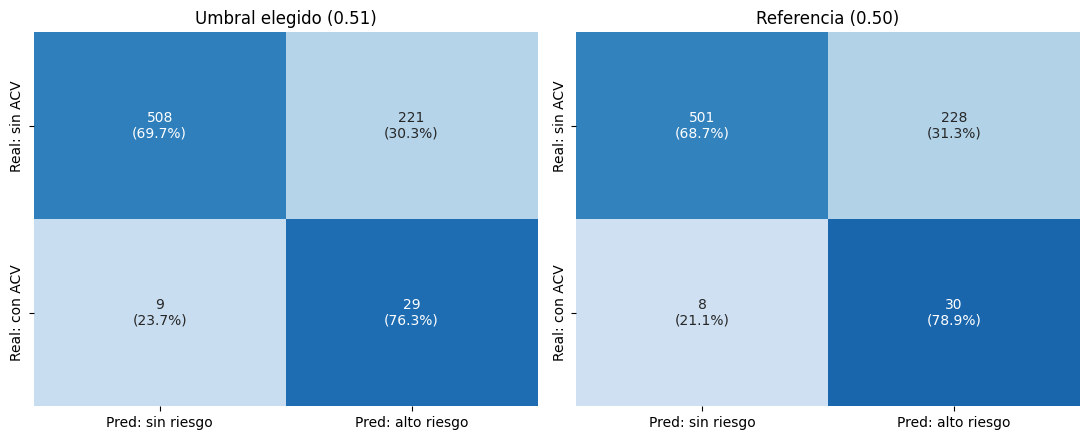

Umbral elegido (0.51): TN=508, FP=221, FN=9, TP=29
  casos con ACV detectados: 29 de 38 (perdidos: 9)
  alertas emitidas: 250, de las cuales ciertas: 29 (11.6%)
  pacientes sanos con falsa alarma: 221 de 729 (30.3%)
Referencia (0.50): TN=501, FP=228, FN=8, TP=30
  casos con ACV detectados: 30 de 38 (perdidos: 8)
  alertas emitidas: 258, de las cuales ciertas: 30 (11.6%)
  pacientes sanos con falsa alarma: 228 de 729 (31.3%)


In [22]:
def confusion_counts(threshold):
    preds = (test_probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(test_labels, preds).ravel()
    return int(tn), int(fp), int(fn), int(tp)

thresholds_to_plot = [(chosen_threshold, 'Umbral elegido'), (0.5, 'Referencia')]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (threshold, title) in zip(axes, thresholds_to_plot):
    tn, fp, fn, tp = confusion_counts(threshold)
    counts = np.array([[tn, fp], [fn, tp]])
    row_pct = counts / counts.sum(axis=1, keepdims=True) * 100
    labels = np.array([[f"{counts[i, j]}\n({row_pct[i, j]:.1f}%)"
                        for j in range(2)] for i in range(2)])
    sns.heatmap(row_pct, annot=labels, fmt='', cmap='Blues', vmin=0, vmax=100,
                cbar=False, ax=ax,
                xticklabels=['Pred: sin riesgo', 'Pred: alto riesgo'],
                yticklabels=['Real: sin ACV', 'Real: con ACV'])
    ax.set_title(f"{title} ({threshold:.2f})")
    ax.grid(False)
plt.tight_layout()
plt.savefig('p1_07_matrices_confusion.png', dpi=110, bbox_inches='tight')
plt.show()

for threshold, title in thresholds_to_plot:
    tn, fp, fn, tp = confusion_counts(threshold)
    print(f"{title} ({threshold:.2f}): TN={tn}, FP={fp}, FN={fn}, TP={tp}")
    print(f"  casos con ACV detectados: {tp} de {tp + fn} "
          f"(perdidos: {fn})")
    print(f"  alertas emitidas: {tp + fp}, de las cuales ciertas: {tp} "
          f"({tp / (tp + fp) * 100:.1f}%)")
    print(f"  pacientes sanos con falsa alarma: {fp} de {tn + fp} "
          f"({fp / (tn + fp) * 100:.1f}%)")


**Lectura con el umbral elegido (0.51).** El modelo clasifica bien a 508
pacientes sin ACV (TN) y detecta 29 de 38 casos con ACV (TP). Comete 221
falsas alarmas (FP, el 30.3% de los sanos) y deja pasar 9 casos (FN, el
23.7% de los enfermos).

**Costo de cada tipo de error.**

- *Falso positivo.* El paciente sano recibe una alerta. El costo es una
  consulta o un estudio extra, y algo de preocupación. La salud del
  paciente no empeora por la alerta.
- *Falso negativo.* El paciente con alto riesgo recibe "sin riesgo". El
  modelo no dispara ningún control ni medida preventiva. El paciente y el médico reciben una tranquilidad falsa. El costo posible es un ACV que no se anticipa, porque el paciente no recibe seguimiento.

Por esta asimetría, los falsos negativos pesan más que los falsos
positivos. Es la razón de fijar un piso de recall en la sección 5.1. El
class weighting (sección 2e) tuvo la misma motivación, pero la sección
7.1 muestra que no mejora la detección.

**Qué aporta el modelo, y qué no.**

- Entre los 250 pacientes con alerta, 29 (11.6%) tuvieron ACV. La tasa
  base en test es 5.0% (38 de 767). La alerta multiplica el riesgo por
  unos 2.3, pero cada caso real cuesta unas 9 alertas.
- Entre los 517 pacientes sin alerta, 9 (1.7%) tuvieron ACV. Un "sin
  riesgo" baja el riesgo de 5.0% a 1.7%. No lo lleva a cero. Por eso el
  resultado negativo del modelo no permite dar de alta a un paciente. El
  modelo sirve para priorizar controles, no para descartar un ACV.

**Umbral 0.50 frente a 0.51.** Pasar de 0.50 a 0.51 agrega 1 caso
perdido (de 8 a 9) y quita 7 falsas alarmas (de 228 a 221). Es decir,
unas 7 falsas alarmas menos por cada caso perdido de más. Si el costo de
un caso perdido supera al de 7 controles extra, 0.50 es mejor. Si no,
0.51 es mejor. Esa comparación es una decisión clínica. Los datos de este trabajo no la resuelven.

## 7. Análisis y conclusiones

### 7.1 Qué decisiones importaron: ablación sobre validación

Para decir qué decisiones de diseño fueron críticas, se mide su efecto en
lugar de suponerlo. Se reentrena el modelo con una decisión cambiada a la
vez, sobre 5 semillas (0 a 4), y se comparan:

- **Base**: Leaky ReLU y `pos_weight`, como en las secciones 3 y 4.
- **Sin `pos_weight`**: `BCEWithLogitsLoss` común.
- **ReLU**: `negative_slope = 0`, con el mismo Kaiming.
- **ReLU sin `pos_weight`**: las dos decisiones cambiadas.
- **Regresión logística**: un modelo lineal, como referencia. No es parte
  de lo que pide el enunciado.

Métricas, todas sobre **validación** (el test no se toca):

- AUC-ROC: mide el orden de los pacientes, sin depender del umbral.
- Recall y pacientes marcados con umbral 0.5: mide el efecto de
  `pos_weight` sobre las probabilidades.
- Precisión con recall >= 0.70: precisión del mejor umbral que cumple la
  regla de la sección 5.1. La búsqueda prueba cada puntaje de validación como umbral, y no una
  grilla fija. El umbral se busca en la misma validación, así que el valor
  es optimista. Sirve para comparar variantes entre sí.
- Unidades inactivas: unidades ocultas con suma ponderada <= 0 para todos
  los ejemplos de train. Es la señal de una neurona muerta en ReLU.

Cada variante usa su propia pérdida para el Early Stopping.

In [23]:
def best_precision_at_min_recall(labels, probs, min_recall):
    # Busqueda exacta: prueba como umbral cada puntaje de validacion, en lugar
    # de una grilla fija. Una grilla de 0.01 tiene pocos puntos utiles cuando
    # las probabilidades son bajas (modelo sin pos_weight).
    precision_curve, recall_curve, _ = precision_recall_curve(labels, probs)
    eligible = recall_curve[:-1] >= min_recall   # el ultimo punto es artificial
    return float(precision_curve[:-1][eligible].max()) if eligible.any() else 0.0


def count_inactive_units(trained_model, x_train_tensor):
    # Cuenta, por capa oculta, las unidades con suma ponderada <= 0 en
    # TODOS los ejemplos de train (modo eval, sin Dropout)
    trained_model.eval()
    inactive_per_layer = []
    with torch.no_grad():
        hidden = x_train_tensor
        for layer in trained_model.net:
            if isinstance(layer, nn.Linear):
                weighted_sum = layer(hidden)
                if layer.out_features != 1:
                    all_non_positive = (weighted_sum <= 0).all(dim=0)
                    inactive_per_layer.append(int(all_non_positive.sum()))
                hidden = weighted_sum
            elif isinstance(layer, nn.LeakyReLU):
                hidden = layer(hidden)
    return inactive_per_layer


def train_variant(seed, leaky_slope, use_pos_weight):
    # Entrena una variante con Early Stopping sobre su propia val_loss
    torch.manual_seed(seed)
    np.random.seed(seed)
    variant_model = StrokeMLP(n_features=X_train_s.shape[1],
                              leaky_slope=leaky_slope).to(DEVICE)
    if use_pos_weight:
        variant_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(DEVICE))
    else:
        variant_criterion = nn.BCEWithLogitsLoss()
    variant_optimizer = torch.optim.Adam(variant_model.parameters(), lr=1e-3)

    best_loss, best_weights, epochs_waiting = float('inf'), None, 0
    for _ in range(MAX_EPOCHS):
        variant_model.train()
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)
            variant_optimizer.zero_grad()
            variant_criterion(variant_model(x_batch), y_batch).backward()
            variant_optimizer.step()
        epoch_val_loss, _, _, _ = evaluate(variant_model, val_loader,
                                           variant_criterion)
        if epoch_val_loss < best_loss - MIN_DELTA:
            best_loss = epoch_val_loss
            best_weights = {k: v.clone() for k, v in variant_model.state_dict().items()}
            epochs_waiting = 0
        else:
            epochs_waiting += 1
        if epochs_waiting >= PATIENCE:
            break
    variant_model.load_state_dict(best_weights)

    _, auc, probs, labels = evaluate(variant_model, val_loader, variant_criterion)
    preds_at_half = (probs >= 0.5).astype(int)
    # Mejor precision entre los umbrales con recall >= MIN_RECALL (seccion 5.1)
    best_precision = best_precision_at_min_recall(labels, probs, MIN_RECALL)
    return {
        'auc': auc,
        'recall_05': recall_score(labels, preds_at_half),
        'flagged_05': int(preds_at_half.sum()),
        'precision_at_min_recall': best_precision,
        'inactive_l2': count_inactive_units(variant_model, x_train_tensor)[1],
        'inactive_l3': count_inactive_units(variant_model, x_train_tensor)[2],
    }


x_train_tensor = torch.tensor(X_train_s.values.astype(np.float32)).to(DEVICE)
ablation_variants = {
    'Base (Leaky ReLU + pos_weight)': (0.01, True),
    'Sin pos_weight': (0.01, False),
    'ReLU + pos_weight': (0.0, True),
    'ReLU sin pos_weight': (0.0, False),
}

ablation_rows = []
for variant_name, (slope, with_weight) in ablation_variants.items():
    runs = pd.DataFrame([train_variant(seed, slope, with_weight)
                         for seed in range(5)])
    ablation_rows.append({
        'Variante': variant_name,
        'AUC val (media +- desvio)': f"{runs.auc.mean():.4f} +- {runs.auc.std():.4f}",
        'Recall @0.5': f"{runs.recall_05.mean():.3f}",
        'Marcados @0.5 (de 766)': f"{runs.flagged_05.mean():.0f}",
        'Precision con recall>=0.70': f"{runs.precision_at_min_recall.mean():.3f}",
        'Inact. capa2 (de 32)': f"{runs.inactive_l2.mean():.1f}",
        'Inact. capa3 (de 16)': f"{runs.inactive_l3.mean():.1f}",
    })

# Referencia lineal: regresion logistica sobre los mismos datos
for reference_name, extra in [('Regresion logistica', {}),
                              ('Regresion logistica (class_weight)',
                               {'class_weight': 'balanced'})]:
    linear_model = LogisticRegression(max_iter=2000, **extra)
    linear_model.fit(X_train_s, y_train)
    linear_auc = roc_auc_score(y_val, linear_model.predict_proba(X_val_s)[:, 1])
    ablation_rows.append({
        'Variante': reference_name,
        'AUC val (media +- desvio)': f"{linear_auc:.4f} (determinista)",
        'Recall @0.5': '-', 'Marcados @0.5 (de 766)': '-',
        'Precision con recall>=0.70': '-',
        'Inact. capa2 (de 32)': '-', 'Inact. capa3 (de 16)': '-',
    })

ablation_table = pd.DataFrame(ablation_rows)
print(ablation_table.to_string(index=False))


                          Variante AUC val (media +- desvio) Recall @0.5 Marcados @0.5 (de 766) Precision con recall>=0.70 Inact. capa2 (de 32) Inact. capa3 (de 16)
    Base (Leaky ReLU + pos_weight)          0.8337 +- 0.0042       0.800                    255                      0.178                  0.0                  0.4
                    Sin pos_weight          0.8225 +- 0.0146       0.000                      0                      0.177                  1.2                  2.0
                 ReLU + pos_weight          0.8321 +- 0.0053       0.795                    253                      0.174                  0.2                  0.4
               ReLU sin pos_weight          0.8244 +- 0.0190       0.000                      0                      0.163                  1.2                  2.2
               Regresion logistica     0.8425 (determinista)           -                      -                          -                    -                    -
Regresion 

**1. El orden de los pacientes (AUC) casi no cambia entre variantes.** Las dos variantes con ponderación de clases quedan en 0.8337 y 0.8321. Las dos variantes sin ponderación quedan más abajo (0.8225 y 0.8244). También cambian más entre semillas (desvío 0.0146 y 0.0190, frente a 0.0042 y 0.0053). La diferencia, de unos 0.01, es menor que el desvío de las variantes sin ponderación. Con 5 semillas no se distingue del ruido. Ni
`pos_weight` ni Leaky ReLU cambian de forma clara cuán bien la red ordena el riesgo.

**2. `pos_weight` mueve las probabilidades, no mejora la detección.** Sin
`pos_weight`, con umbral 0.5 el modelo no marca a ningún paciente (recall
0). Con `pos_weight`, marca 255 y logra recall 0.800. Pero la precisión
con recall >= 0.70 es igual en los dos casos (0.178 con `pos_weight` y 0.177 sin él). Al
elegir el umbral sobre validación, como se hace en la sección 5.1,
`pos_weight` no agrega calidad de detección. Sirve para que el umbral 0.5
tenga sentido. Esto corrige la justificación de la sección 2e: en esta
medición, el class weighting equivale a bajar el umbral y no mejora la
detección. La búsqueda de umbral es exacta: prueba cada puntaje como
umbral, porque una grilla fija tiene pocas opciones cuando las
probabilidades son bajas.

**3. Leaky ReLU no mostró ventaja medible.** El AUC con ReLU (0.8321) es
casi igual al de Leaky ReLU (0.8337). Con `pos_weight`, ReLU deja en promedio 0.2 unidades inactivas de 32 en la capa 2, y 0.4 de 16 en la capa 3. Leaky ReLU deja 0.0 y 0.4. La diferencia es menor que una unidad. No hay neuronas muertas a un nivel que dañe el resultado.
Sin `pos_weight` hay más unidades inactivas (1.2 y 2.0 con Leaky ReLU, 1.2 y 2.2 con ReLU). Es lo contrario de lo
que se planteó en la sección 3: `pos_weight` no aumentó el riesgo de
neuronas muertas. Esa hipótesis no se sostiene con esta medición. Leaky
ReLU queda como precaución coherente con el apunte de la Unidad 1, sin un
beneficio demostrado aquí.

**4. Un modelo lineal supera al MLP en esta validación.** La regresión logística
obtiene AUC 0.8425 y 0.8434 en validación, frente a 0.8337 del MLP. La diferencia (0.009) es unas 2 veces el desvío entre semillas de la base (0.0042). Pero ese desvío no incluye el ruido de la validación, que tiene solo 37 positivos. No prueba que el modelo lineal sea mejor en general.
No hay evidencia de que el MLP gane algo con su no linealidad en estos datos.
Todas las variantes llegan a un AUC cercano a 0.83. Eso sugiere que el límite está en la información de las variables, no en la arquitectura.

**Alcance de la medición.** Son 5 semillas, sobre una sola división de los
datos y solo en validación. El desvío entre semillas no incluye la
variabilidad por elegir otra división. El modelo principal de las secciones 4 y 5 tiene un AUC de validación de 0.8331. Queda muy cerca de la media de la variante base (0.8337).

### 7.2 Ablación de las decisiones restantes

La sección 7.1 midió `pos_weight` y Leaky ReLU. Aquí se miden las otras cuatro decisiones, con el mismo protocolo. Se cambia una decisión a la vez, y la comparación se hace sobre **validación**. El test no se toca. Se usan 10 semillas, porque con 5 el ruido entre semillas
(de 0.004 a 0.019 de AUC en la sección 7.1) tapaba diferencias chicas.

- **Inicialización**: Kaiming (base) frente al valor por defecto de PyTorch.
- **Tamaño de la red**: 16-8, 32-16, 64-32-16 (base), 128-64-32 y
  256-128-64 neuronas por capa oculta.
- **Dropout**: 0.0, 0.1, 0.3 (base) y 0.5.
- **Imputación de `bmi`**: mediana de train (base), media de train,
  mediana más una columna que marca los faltantes, KNN con 5 vecinos, y
  sin usar `bmi`. Cada estrategia se ajusta solo con train.

Como las semillas son las mismas en todas las variantes, cada
variante se compara con la base **semilla por semilla**. Se reporta la diferencia media de AUC con su error estándar (desvío / raíz de 10). También se cuenta en cuántas de las 10 semillas la variante supera a la base. Una diferencia menor que
dos errores estándar no se distingue del ruido.

Antes de comparar, se hacen dos chequeos. La variante base reproduce el AUC de la sección 7.1. La imputación por mediana reconstruida aquí da las mismas features que la sección 2.

In [24]:
def build_bmi_variant(imputation):
    # Reconstruye las features de train y val con otra estrategia para bmi.
    # Parte de las columnas ya codificadas (seccion 2c) y restaura los bmi
    # faltantes originales, que la seccion 2b habia rellenado.
    train_features = X_train_enc.astype(float)
    val_features = X_val_enc.astype(float)
    train_features['bmi'] = df_p.loc[train_features.index, 'bmi']
    val_features['bmi'] = df_p.loc[val_features.index, 'bmi']

    numeric_cols = ['age', 'avg_glucose_level', 'bmi']
    if imputation == 'sin bmi':
        train_features = train_features.drop(columns=['bmi'])
        val_features = val_features.drop(columns=['bmi'])
        numeric_cols = ['age', 'avg_glucose_level']
    elif imputation == 'mediana + indicador':
        train_features['bmi_faltante'] = train_features['bmi'].isna().astype(float)
        val_features['bmi_faltante'] = val_features['bmi'].isna().astype(float)

    if imputation in ('mediana', 'mediana + indicador', 'media'):
        fill_value = (train_features['bmi'].mean() if imputation == 'media'
                      else train_features['bmi'].median())
        train_features['bmi'] = train_features['bmi'].fillna(fill_value)
        val_features['bmi'] = val_features['bmi'].fillna(fill_value)

    # Escalado ajustado solo con train (StandardScaler ignora los NaN)
    bmi_scaler = StandardScaler().fit(train_features[numeric_cols])
    train_features[numeric_cols] = bmi_scaler.transform(train_features[numeric_cols])
    val_features[numeric_cols] = bmi_scaler.transform(val_features[numeric_cols])

    if imputation == 'knn':
        knn_imputer = KNNImputer(n_neighbors=5).fit(train_features)
        train_matrix = knn_imputer.transform(train_features)
        val_matrix = knn_imputer.transform(val_features)
    else:
        train_matrix, val_matrix = train_features.values, val_features.values
    return train_matrix.astype(np.float32), val_matrix.astype(np.float32)


def train_general(seed, train_matrix, val_matrix, model_kwargs):
    # Igual que train_variant (7.1), pero con features y arquitectura variables
    torch.manual_seed(seed)
    np.random.seed(seed)
    general_train_loader = DataLoader(
        TensorDataset(torch.tensor(train_matrix),
                      torch.tensor(y_train.astype(np.float32))),
        batch_size=BATCH_SIZE, shuffle=True)
    general_val_loader = DataLoader(
        TensorDataset(torch.tensor(val_matrix),
                      torch.tensor(y_val.astype(np.float32))),
        batch_size=BATCH_SIZE, shuffle=False)
    general_model = StrokeMLP(n_features=train_matrix.shape[1],
                              **model_kwargs).to(DEVICE)
    general_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(DEVICE))
    general_optimizer = torch.optim.Adam(general_model.parameters(), lr=1e-3)

    best_loss, best_weights, best_epoch, epochs_waiting = float('inf'), None, 0, 0
    for epoch in range(1, MAX_EPOCHS + 1):
        general_model.train()
        for x_batch, y_batch in general_train_loader:
            x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)
            general_optimizer.zero_grad()
            general_criterion(general_model(x_batch), y_batch).backward()
            general_optimizer.step()
        epoch_val_loss, _, _, _ = evaluate(general_model, general_val_loader,
                                           general_criterion)
        if epoch_val_loss < best_loss - MIN_DELTA:
            best_loss, best_epoch, epochs_waiting = epoch_val_loss, epoch, 0
            best_weights = {k: v.clone() for k, v in general_model.state_dict().items()}
        else:
            epochs_waiting += 1
        if epochs_waiting >= PATIENCE:
            break
    general_model.load_state_dict(best_weights)

    _, auc, probs, labels = evaluate(general_model, general_val_loader,
                                     general_criterion)
    best_precision = best_precision_at_min_recall(labels, probs, MIN_RECALL)
    return {'auc': auc, 'precision': best_precision, 'epoch': best_epoch,
            'params': sum(p.numel() for p in general_model.parameters())}


# Features por estrategia de imputacion (se construyen una sola vez)
bmi_strategies = ['mediana', 'media', 'mediana + indicador', 'knn', 'sin bmi']
bmi_matrices = {name: build_bmi_variant(name) for name in bmi_strategies}

# Chequeo 1: la mediana reconstruida coincide con las features de la seccion 2
same_features = np.allclose(bmi_matrices['mediana'][0],
                            X_train_s.values.astype(np.float32))
print(f"Chequeo: features con mediana == features de la seccion 2: {same_features}")

# (grupo, nombre, estrategia de bmi, argumentos del modelo)
ablation_specs = [
    ('Base', 'Base (Kaiming, 64-32-16, Dropout 0.3, mediana)', 'mediana', {}),
    ('Inicializacion', 'Init por defecto de PyTorch', 'mediana', {'kaiming_init': False}),
    ('Tamaño', '16-8', 'mediana', {'hidden_sizes': (16, 8)}),
    ('Tamaño', '32-16', 'mediana', {'hidden_sizes': (32, 16)}),
    ('Tamaño', '128-64-32', 'mediana', {'hidden_sizes': (128, 64, 32)}),
    ('Tamaño', '256-128-64', 'mediana', {'hidden_sizes': (256, 128, 64)}),
    ('Dropout', 'Dropout 0.0', 'mediana', {'dropout': 0.0}),
    ('Dropout', 'Dropout 0.1', 'mediana', {'dropout': 0.1}),
    ('Dropout', 'Dropout 0.5', 'mediana', {'dropout': 0.5}),
    ('Imputacion bmi', 'Media', 'media', {}),
    ('Imputacion bmi', 'Mediana + indicador de faltante', 'mediana + indicador', {}),
    ('Imputacion bmi', 'KNN (k=5)', 'knn', {}),
    ('Imputacion bmi', 'Sin bmi', 'sin bmi', {}),
]

N_SEEDS = 10
per_seed_results = {}
for group, name, strategy, kwargs in ablation_specs:
    train_matrix, val_matrix = bmi_matrices[strategy]
    per_seed_results[name] = pd.DataFrame(
        [train_general(seed, train_matrix, val_matrix, kwargs)
         for seed in range(N_SEEDS)])

base_name = ablation_specs[0][1]
base_auc = per_seed_results[base_name]['auc'].values

# Chequeo 2: las primeras 5 semillas de la base reproducen la seccion 7.1
print(f"Chequeo: AUC base, semillas 0-4: {base_auc[:5].mean():.4f} "
      f"(seccion 7.1: 0.8327)")

table_rows = []
for group, name, strategy, kwargs in ablation_specs:
    runs = per_seed_results[name]
    diff = runs['auc'].values - base_auc
    is_base = name == base_name
    table_rows.append({
        'Grupo': group,
        'Variante': name.split(' (')[0] if is_base else name,
        'Params': int(runs['params'].iloc[0]),
        'AUC val': f"{runs['auc'].mean():.4f} +- {runs['auc'].std():.4f}",
        'Dif. vs base (EE)': '-' if is_base else
            f"{diff.mean():+.4f} ({diff.std(ddof=1) / np.sqrt(N_SEEDS):.4f})",
        'Mejor que base': '-' if is_base else f"{int((diff > 0).sum())}/{N_SEEDS}",
        'Prec. recall>=0.70': f"{runs['precision'].mean():.3f}",
        'Epoca (min-max)': (f"{runs['epoch'].mean():.1f} "
                            f"({runs['epoch'].min()}-{runs['epoch'].max()})"),
    })
print()
print(pd.DataFrame(table_rows).to_string(index=False))

# Diferencia vs base sin las corridas fallidas (AUC < 0.75 en la variante o la base)
print()
print("Diferencia vs base sin corridas fallidas (AUC < 0.75):")
for group, name, strategy, kwargs in ablation_specs[1:]:
    variant_auc = per_seed_results[name]['auc'].values
    valid_seeds = (variant_auc >= 0.75) & (base_auc >= 0.75)
    if valid_seeds.sum() < N_SEEDS:
        diff = variant_auc[valid_seeds] - base_auc[valid_seeds]
        print(f"  {name}: {diff.mean():+.4f} "
              f"(EE {diff.std(ddof=1) / np.sqrt(len(diff)):.4f}), "
              f"{len(diff)} de {N_SEEDS} semillas")

# Desvio de los pesos de la primera capa segun la inicializacion
torch.manual_seed(0)
n_input_features = bmi_matrices['mediana'][0].shape[1]
std_kaiming = StrokeMLP(n_input_features).net[0].weight.std().item()
std_default = StrokeMLP(n_input_features, kaiming_init=False).net[0].weight.std().item()
print(f"\nDesvio de los pesos de la 1a capa: Kaiming {std_kaiming:.4f}, "
      f"default de PyTorch {std_default:.4f} "
      f"(varianza {std_kaiming**2 / std_default**2:.1f} veces mayor)")


Chequeo: features con mediana == features de la seccion 2: True
Chequeo: AUC base, semillas 0-4: 0.8337 (seccion 7.1: 0.8327)

         Grupo                        Variante  Params          AUC val Dif. vs base (EE) Mejor que base Prec. recall>=0.70 Epoca (min-max)
          Base                            Base    3841 0.8333 +- 0.0058                 -              -              0.180       3.8 (2-6)
Inicializacion     Init por defecto de PyTorch    3841 0.8346 +- 0.0061  +0.0013 (0.0034)           5/10              0.167      6.5 (3-14)
        Tamaño                            16-8     449 0.8306 +- 0.0071  -0.0027 (0.0028)           5/10              0.191     16.7 (7-31)
        Tamaño                           32-16    1153 0.8229 +- 0.0233  -0.0104 (0.0083)           3/10              0.168      9.0 (3-24)
        Tamaño                       128-64-32   12801 0.8309 +- 0.0068  -0.0024 (0.0025)           4/10              0.174      3.9 (1-13)
        Tamaño                   

**Chequeos.** Los dos pasan. La mediana reconstruida da las mismas
features que la sección 2. La variante base reproduce el AUC de la
sección 7.1 en las semillas 0 a 4 (0.8337). Con 10 semillas, la base queda
en 0.8333 +- 0.0058.

**Resultado principal: casi ninguna decisión tiene un efecto
medible.** Solo una diferencia con la base supera dos errores estándar. Es la mediana más un indicador de faltante (+0.0062, 2.6 errores estándar, 8 de 10 semillas).
Con 12 comparaciones, el azar produce en promedio una diferencia de
ese tamaño (12 x 0.05 = 0.6). Por eso ese resultado es una señal débil, no un efecto demostrado.

- *Inicialización.* Kaiming y el valor por defecto de PyTorch dan el
  mismo AUC (+0.0013, error estándar 0.0034). Los pesos iniciales no son iguales. El desvío de la primera capa es 0.3306 con Kaiming y 0.1358 con el default, una varianza 5.9 veces mayor. Una red de 3 capas con
  Adam no es sensible a esa diferencia. Declarar Kaiming documenta la
  decisión, no mejora el modelo.
- *Tamaño de la red.* La red de 256-128-64 tiene 46081 parámetros.
  Son unas 12.9 veces las filas de train. Da un AUC equivalente al de la base
  (-0.0018, error estándar 0.0029).
  La idea inicial de la sección 3, que una red grande sobreajusta más, no
  se sostiene. Los cuatro tamaños quedan un poco por debajo de la base, de -0.0018 a -0.0104. La red 32-16 baja más (-0.0104, error estándar 0.0083), con el desvío más alto entre semillas (0.0233). Ningún tamaño llega a dos errores estándar.
- *Dropout.* Con Dropout 0.0 el AUC es 0.8352, igual a la base (+0.0019,
  error estándar 0.0016). Dropout 0.1 es la mejor variante de Dropout (+0.0021, 8 de
  10 semillas). Queda en 1.9 errores estándar, sin llegar a dos. Un Dropout alto retrasa el
  entrenamiento: la época media sube de 3.8 a 7.8 con 0.5 (rango de 3 a 14).
- *Imputación de `bmi`.* Media (+0.0003), KNN (+0.0006) y no usar `bmi` (-0.0028) quedan dentro del ruido o muy cerca de él. KNN llega a unos 2 errores estándar, pero su diferencia es de solo 0.0006 de AUC. Quitar
  `bmi` por completo no cambia el AUC de forma medible. Es coherente con
  su correlación baja (0.042) en la sección 1: si la variable aporta poco,
  la forma de rellenarla importa poco. La mediana con indicador da +0.0062. El indicador agrega una columna que marca si el dato falta. Es información nueva, no otra forma de rellenar.

**Paradas muy tempranas.** Ninguna corrida tuvo un AUC menor que 0.75. Por eso la lista de diferencias sin corridas fallidas queda vacía. Pero cuatro variantes tienen al menos una corrida que conservó los pesos de la
época 1. Son 128-64-32, 256-128-64, Dropout 0.0 y Dropout 0.1. En la variante base, la época elegida va
de 2 a 6 según la semilla. El modelo principal de la sección 4 eligió la época 10, fuera de ese rango. Es una fragilidad del criterio de parada.

**Precisión con recall >= 0.70.** Va de 0.162 a 0.191 en todas las
variantes. Es una métrica ruidosa, y el umbral se busca en la misma validación. No distingue variantes.

**Alcance.** Los errores estándar van de 0.0003 a 0.0034 (sin contar
32-16). La medición descarta efectos de más de unos 0.007 de AUC. No
descarta efectos chicos. Es una sola división de datos, y validación tiene
solo 37 positivos.

**Consecuencia.** Con la sección 7.1, ninguna decisión de diseño cambia el AUC de forma clara. Todas las variantes del MLP dan
un AUC entre 0.82 y 0.84, y la regresión logística llega a 0.84. La mejor variante del MLP (0.8395) queda debajo de la regresión logística (0.8425). Esto apoya
que el límite del modelo está en los datos y no en la arquitectura.

### 7.3 La edad como variable de confusión

En la sección 1, `age` fue el predictor más fuerte. Otras variables son en parte proxies de la edad. Si lo son, la red no separa su efecto del
de la edad. Se comparan la edad media y la tasa de ACV por categoría de
`work_type` y `smoking_status`, sobre el dataset completo. Es un chequeo
descriptivo. No prueba causalidad.

In [25]:
for categorical_col in ['work_type', 'smoking_status']:
    age_summary = df.groupby(categorical_col).agg(
        pacientes=('age', 'size'),
        edad_media=('age', 'mean'),
        tasa_acv_pct=('stroke', lambda s: s.mean() * 100),
    ).round(1)
    print(age_summary.to_string())
    print()


               pacientes  edad_media  tasa_acv_pct
work_type                                         
Govt_job             657        50.9           5.0
Never_worked          22        16.2           0.0
Private             2925        45.5           5.1
Self-employed        819        60.2           7.9
children             687         6.8           0.3

                 pacientes  edad_media  tasa_acv_pct
smoking_status                                      
Unknown               1544        30.2           3.0
formerly smoked        885        54.9           7.9
never smoked          1892        46.7           4.8
smokes                 789        47.1           5.3



`work_type = children` tiene una edad media de 6.8 años y una tasa de ACV
de 0.3%. `Self-employed` tiene la edad media más alta (60.2 años) y la
mayor tasa de todas las categorías de trabajo (7.9%).
`smoking_status = Unknown` tiene una edad media de 30.2 años y la tasa más
baja (3.0%), y `formerly smoked` tiene 54.9 años y 7.9%.

El patrón es consistente con que estas variables sean en parte proxies de la edad. Las categorías con mayor tasa de ACV son también las de mayor edad. Con estos datos, la red no separa el efecto de `smoking_status` o `work_type` del efecto de la edad. Los pesos de la red no se interpretan
como efectos causales de cada variable.

### 7.4 Conclusiones

**Resultado.** El MLP aprende señal real (AUC-ROC 0.8177 en test), pero
es un filtro débil. Con el umbral 0.51 detecta 29 de 38 casos y deja
pasar 9. De cada 9 alertas, unas 8 son falsas. El modelo sirve para priorizar
controles, no para descartar un ACV (sección 6).

**Limitaciones del modelo**

1. *Pocos positivos.* Train tiene 174, validación 37 y test 38. Un
   paciente mueve el recall unos 2.7 puntos. El recall bajó de 0.811 en
   validación a 0.7632 en test. Todo el resultado sale de una división y
   una semilla, sin intervalo de confianza.
2. *Sin ganancia sobre un modelo lineal.* La regresión logística supera al MLP en validación (0.8425 frente a 0.8337, sección 7.1). La diferencia es de unos 2 desvíos entre semillas. Sale de una sola validación con 37 positivos, así que no es concluyente.
3. *Variables confundidas con la edad.* `work_type` y `smoking_status`
   siguen a la edad (sección 7.3). La red no separa sus efectos.
4. *Las salidas no son probabilidades de riesgo.* `pos_weight` distorsiona
   las probabilidades. Un puntaje de 0.51 no significa 51% de riesgo. Los
   pacientes con alerta tuvieron 11.6% de ACV.
5. *La regla del umbral es sensible.* La precisión de validación es casi plana entre 0.49 y 0.56. Pocos pacientes de validación cambian la elección.
6. *El criterio de parada es inestable.* La época elegida cambia
   entre semillas: de 2 a 6 en la variante base. En el modelo principal es
   la 10 (paró en la 20), fuera de ese rango. Al menos una corrida conservó la época 1 en cuatro
   variantes de la sección 7.2. Ninguna corrida tuvo un AUC menor que 0.75.
7. *Resolución limitada de las ablaciones.* Usan una división de datos y
   validación con 37 positivos. Descartan efectos de más de unos 0.007 de
   AUC, y no efectos chicos.

**Decisiones de diseño: qué importó, según la medición**

- *El umbral.* Con la ponderación de clases, la regla de la sección 5.1 eligió 0.51, casi igual a 0.50. En test, el efecto fue chico. Las falsas alarmas bajan de 228 a 221, y el recall baja de
  0.7895 a 0.7632. El F1 baja de 0.2027 a 0.2014. Elegir el umbral sigue siendo necesario: sin ponderación, el umbral 0.5 no marca a ningún paciente (sección 7.1).
- *La métrica.* La accuracy engaña: una regla que siempre predice "sin
  ACV" tiene 0.9505, más que el modelo (0.7001).
- *Separar validación y test.* El recall fue 0.811 en validación y 0.7632
  en test. El recall de validación es unos 5 puntos mayor que el de test. Reportar validación sobreestima el recall.
- *Sin efecto medible sobre el AUC de validación.* Esto vale para
  `pos_weight`, que mueve las probabilidades pero no la detección. Vale
  para Leaky ReLU frente a ReLU y para la inicialización Kaiming. Vale
  para el tamaño de la red (de 449 a 46081 parámetros) y para Dropout (de
  0.0 a 0.5). Vale también para no usar `bmi`. Solo el indicador de faltante supera dos errores estándar (+0.0062), un efecto chico entre 12 comparaciones.
  Ver las secciones 7.1 y 7.2.
- *Qué no se midió:* la tasa de aprendizaje, el tamaño del batch, la
  regularización L2 y otra división de los datos.

Las decisiones sin efecto no fueron un error. Siguen el apunte de la
materia o el sentido común, y no dañan el resultado. Lo que cambia es la
justificación. Dos argumentos no se sostuvieron al medirlos: que
`pos_weight` aumenta las neuronas muertas, y que una red más grande
sobreajusta más.

**Mejoras futuras**

- Usar validación cruzada estratificada repetida. Da un intervalo de
  confianza del AUC y del recall, y permite elegir el umbral con menos
  varianza.
- Elegir el umbral con un costo clínico explícito de falso negativo y de
  falsa alarma, en lugar de un piso de recall fijo.
- Cambiar el criterio de Early Stopping, por ejemplo usar el AUC de
  validación o promediar varias épocas, para evitar paradas en épocas
  malas.
- Calibrar las probabilidades (por ejemplo con regresión isotónica), para
  que el puntaje se interprete como riesgo.
- Comparar con modelos de referencia (lineal, árboles). Si el MLP no los
  supera, un modelo lineal es más simple de interpretar.
- Medir la tasa de aprendizaje, el tamaño del batch y la regularización
  L2. No se midieron en este trabajo.
- Conseguir más casos positivos o más variables clínicas. La ablación
  sugiere que el límite está en los datos.